# Human in the loop

In [27]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [28]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [29]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [30]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

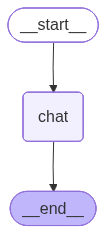

In [31]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
builder.compile(checkpointer=checkpointer)

In [32]:
app = builder.compile(checkpointer=checkpointer)

In [33]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [34]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='8066088e-ac20-4a8f-bc4e-af67e85bffc4')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='1cc22a9b61a1da76f49b3682e5d1188e')]}

In [35]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [36]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [37]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [39]:
final_result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='8066088e-ac20-4a8f-bc4e-af67e85bffc4'),
  AIMessage(content="Sure! Imagine you're standing on a hill covered in fog, and you want to find the lowest point in the valley. Since you can't see far, you look around your feet and figure out which direction goes downhill the most. Then you take a small step that way. You keep doing this—looking for the steepest downward slope around you and taking small steps in that direction—until you reach the bottom.\n\nGradient descent is like that, but for math problems. It’s a way to find the minimum of a function by taking small steps downhill, guided by the slope (called the gradient), until you can’t go any lower. This is very useful for training things like machine learning models!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 15, 'total_tokens': 

In [38]:
print(final_result["messages"][-1].content)

Sure! Imagine you're standing on a hill covered in fog, and you want to find the lowest point in the valley. Since you can't see far, you look around your feet and figure out which direction goes downhill the most. Then you take a small step that way. You keep doing this—looking for the steepest downward slope around you and taking small steps in that direction—until you reach the bottom.

Gradient descent is like that, but for math problems. It’s a way to find the minimum of a function by taking small steps downhill, guided by the slope (called the gradient), until you can’t go any lower. This is very useful for training things like machine learning models!
